# 🚢 Titanic Survival Prediction (Binary Classification)

---
A classic binary classification problem: predict whether a passenger **survived** based on ticket class, sex, age, number of relatives aboard, fare paid...

## 🎯 Goals
- Explore the factors that drive survival (sex, ticket class, age, family size...).
- Build feature engineering: `Title`, `FamilySize`, `IsAlone`, `HasCabin`, `FarePerPerson`, `AgeGroup`.
- Compare 3 classifiers (Logistic Regression, Random Forest, XGBoost) within the same preprocessing pipeline.
- Pick the best model by **F1-score**, analyze the confusion matrix & feature importance.
- Retrain on the full dataset and generate a Kaggle submission file (`outputs/submission.csv`).

> Original dataset: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic) (already included in `data/train.csv`, `data/test.csv`).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "Survived"

DATA_DIR = Path("data")
ASSETS = Path("docs/assets"); ASSETS.mkdir(parents=True, exist_ok=True)
OUTPUTS = Path("outputs"); OUTPUTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)
print("Setup OK")

Setup OK


## 🔹 Step 1: Load the data

Read `data/train.csv` (labeled with `Survived`) and `data/test.csv` (used to generate the Kaggle submission, unlabeled).

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")
print(f"Survival rate (train): {train_df[TARGET].mean()*100:.2f}%")
train_df.head()

Train: (891, 12)  |  Test: (418, 11)
Survival rate (train): 38.38%


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🔹 Step 2: General EDA

Check data types, missing-value ratio, and the target label distribution.

In [3]:
missing = train_df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print("Missing ratio (train):")
print((missing * 100).round(2).astype(str) + " %")
train_df.describe(include="all").T[["count", "unique", "mean", "std"]].head(12)

Missing ratio (train):
Cabin        77.1 %
Age         19.87 %
Embarked     0.22 %
dtype: object


,count,unique,mean,std
PassengerId,891.0,NaN,446.0,257.353842
Survived,891.0,NaN,0.383838,0.486592
Pclass,891.0,NaN,2.308642,0.836071
Name,891,891,NaN,NaN
Sex,891,2,NaN,NaN
Age,714.0,NaN,29.699118,14.526497
SibSp,891.0,NaN,0.523008,1.102743
Parch,891.0,NaN,0.381594,0.806057
Ticket,891,681,NaN,NaN
Fare,891.0,NaN,32.204208,49.693429


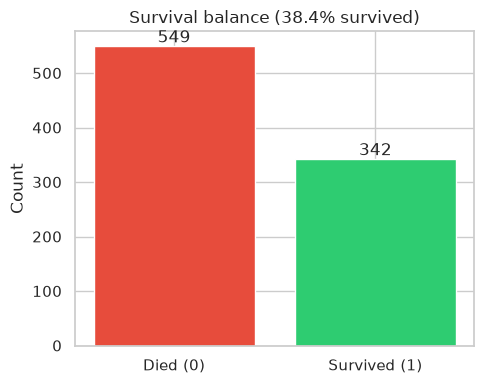

In [4]:
counts = train_df[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Died (0)", "Survived (1)"], counts.values, color=["#e74c3c", "#2ecc71"])
ax.set_ylabel("Count")
ax.set_title(f"Survival balance ({train_df[TARGET].mean()*100:.1f}% survived)")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(ASSETS / "survival_balance.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 3: Survival by passenger characteristics

`Sex` and `Pclass` are the two features most strongly correlated with survival ("women and children first", and first-class passengers were prioritized during rescue).

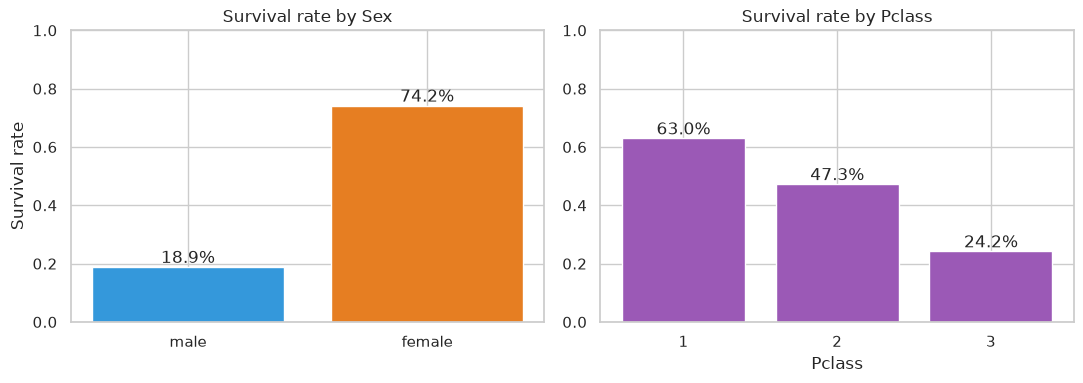

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sex_rate = train_df.groupby("Sex")[TARGET].mean().reindex(["male", "female"])
axes[0].bar(sex_rate.index, sex_rate.values, color=["#3498db", "#e67e22"])
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Survival rate")
axes[0].set_title("Survival rate by Sex")
for i, v in enumerate(sex_rate.values):
    axes[0].text(i, v, f"{v*100:.1f}%", ha="center", va="bottom")

pclass_rate = train_df.groupby("Pclass")[TARGET].mean().sort_index()
axes[1].bar(pclass_rate.index.astype(str), pclass_rate.values, color="#9b59b6")
axes[1].set_ylim(0, 1); axes[1].set_xlabel("Pclass")
axes[1].set_title("Survival rate by Pclass")
for i, v in enumerate(pclass_rate.values):
    axes[1].text(i, v, f"{v*100:.1f}%", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(ASSETS / "survival_by_feature.png", dpi=120, bbox_inches="tight")
plt.show()

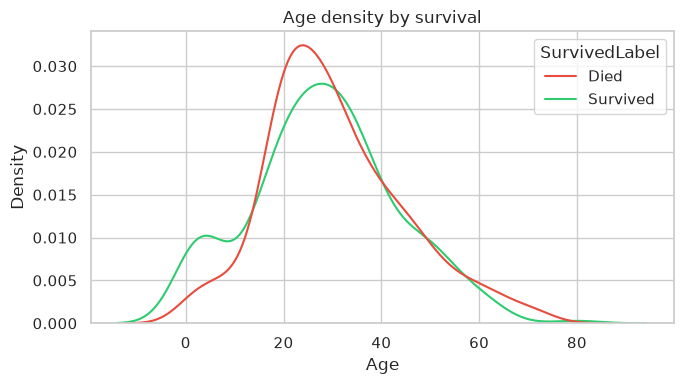

In [6]:
# Age distribution by survival (missing ages dropped just for this plot)
age_plot_df = train_df.assign(SurvivedLabel=train_df[TARGET].map({0: "Died", 1: "Survived"}))
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=age_plot_df, x="Age", hue="SurvivedLabel", common_norm=False, ax=ax,
            palette={"Died": "#e74c3c", "Survived": "#2ecc71"})
ax.set_title("Age density by survival")
fig.tight_layout()
plt.show()

## 🔹 Step 4: Feature engineering

Derive new features from the raw data:
- **Title**: honorific extracted from `Name` (Mr/Mrs/Miss/Master/Others).
- **FamilySize** = `SibSp + Parch + 1`, **IsAlone** = traveling alone or not.
- **HasCabin**: whether a cabin number was recorded (missing cabin data correlates with a lower ticket class).
- **AgeGroup**: missing ages are filled with the `(Pclass, Sex)` group median, then bucketed.
- **FarePerPerson** / **LogFarePerPerson**: fare split evenly across family members, then log-transformed since it's heavily right-skewed.

`age_medians` is computed **on the train set only** and reused for the test set to avoid data leakage.

In [7]:
TITLE_MAP = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs", "Dr": "Mr", "Sir": "Mr",
    "Major": "Mr", "Col": "Mr", "Capt": "Mr", "Rev": "Mr", "Jonkheer": "Mr",
    "Don": "Mr", "Countess": "Mrs", "Lady": "Mrs",
}
KNOWN_TITLES = {"Mr", "Mrs", "Miss", "Master"}
AGE_BINS = [-1, 12, 18, 35, 60, 100]
AGE_LABELS = ["Child", "Teenager", "YoungAdult", "Adult", "Senior"]


def engineer_features(df: pd.DataFrame, age_medians: pd.Series, fare_median: float,
                       embarked_mode: str) -> pd.DataFrame:
    """Derive model-ready features. `age_medians`/`fare_median`/`embarked_mode`
    must come from the *train* split only, to avoid leaking test statistics."""
    df = df.copy()

    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")[0].str.strip()
    df["Title"] = df["Title"].replace(TITLE_MAP)
    df.loc[~df["Title"].isin(KNOWN_TITLES), "Title"] = "Others"

    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    df["HasCabin"] = df["Cabin"].notna().astype(int)

    age_lookup = age_medians.rename("AgeMedian").reset_index()
    df = df.merge(age_lookup, on=["Pclass", "Sex"], how="left")
    df["Age"] = df["Age"].fillna(df["AgeMedian"]).fillna(age_medians.median())
    df["AgeGroup"] = pd.cut(df["Age"], bins=AGE_BINS, labels=AGE_LABELS)

    df["Embarked"] = df["Embarked"].fillna(embarked_mode)
    df["Fare"] = df["Fare"].fillna(fare_median)
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"]
    df["LogFarePerPerson"] = np.log1p(df["FarePerPerson"])

    return df.drop(columns=["AgeMedian"])


def fit_train_stats(df: pd.DataFrame) -> dict:
    return {
        "age_medians": df[df["Age"].notna()].groupby(["Pclass", "Sex"])["Age"].median(),
        "fare_median": float(df["Fare"].median()),
        "embarked_mode": df["Embarked"].mode()[0],
    }


NUM_FEATURES = ["FamilySize", "FarePerPerson", "LogFarePerPerson"]
CAT_FEATURES = ["Sex", "Pclass", "Embarked", "Title", "AgeGroup", "IsAlone", "HasCabin"]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

train_stats = fit_train_stats(train_df)
train_engineered = engineer_features(train_df, **train_stats)
train_engineered[["Name", "Title", "FamilySize", "IsAlone", "HasCabin", "AgeGroup", "FarePerPerson"]].head()

,Name,Title,FamilySize,IsAlone,HasCabin,AgeGroup,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,2,0,0,YoungAdult,3.62500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,1,Adult,35.64165
2,"Heikkinen, Miss. Laina",Miss,1,1,0,YoungAdult,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,1,YoungAdult,26.55000
4,"Allen, Mr. William Henry",Mr,1,1,0,YoungAdult,8.05000


## 🔹 Step 5: Train/holdout split (stratified) & preprocessing pipeline

`stratify=y` preserves the survival ratio in both sets. Preprocessing is packaged in a `ColumnTransformer`: numeric → median impute + `StandardScaler`; categorical → most-frequent impute + `OneHotEncoder`.

In [8]:
X = train_engineered[ALL_FEATURES]
y = train_engineered[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}  survived={y_train.mean()*100:.1f}%")
print(f"Holdout: {X_test.shape}  survived={y_test.mean()*100:.1f}%")


def build_preprocessor() -> ColumnTransformer:
    num_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", num_pipe, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
    ])

Train: (712, 10)  survived=38.3%
Holdout: (179, 10)  survived=38.5%


## 🔹 Step 6: Comparing 3 models

| Model | Idea |
|---|---|
| **Logistic Regression** | Linear baseline, easy to interpret via regression coefficients |
| **Random Forest** | Bagged decision trees, captures non-linear interactions |
| **XGBoost** | Gradient boosting, usually the strongest choice on small tabular datasets |

Each model reuses the same `ColumnTransformer` above, wrapped in a `Pipeline` to avoid data leakage during scaling/encoding.

In [9]:
def make_pipeline(estimator) -> Pipeline:
    return Pipeline([("preprocess", build_preprocessor()), ("model", estimator)])


models = {
    "logreg": make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "random_forest": make_pipeline(RandomForestClassifier(
        n_estimators=300, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)),
    "xgboost": make_pipeline(XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.9,
        colsample_bytree=0.9, eval_metric="logloss", random_state=RANDOM_STATE)),
}

results = []
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted[name] = {"pipe": pipe, "pred": pred}
    results.append({
        "model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })

leaderboard = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
leaderboard

,model,Accuracy,F1
0,logreg,0.849162,0.802920
1,xgboost,0.815642,0.755556
2,random_forest,0.821229,0.753846


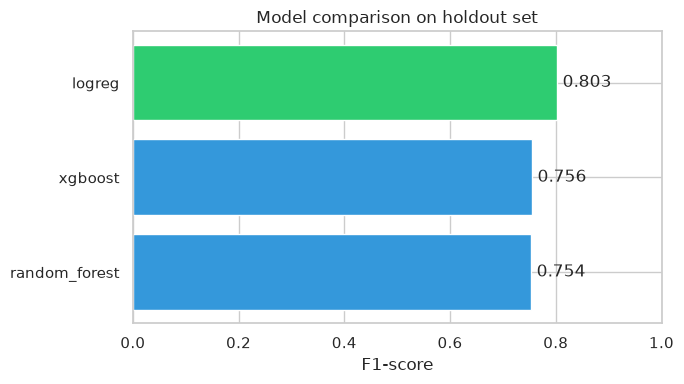

In [10]:
lb = leaderboard.sort_values("F1")
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2ecc71" if v == lb["F1"].max() else "#3498db" for v in lb["F1"]]
bars = ax.barh(lb["model"], lb["F1"], color=colors)
ax.set_xlim(0, 1); ax.set_xlabel("F1-score")
ax.set_title("Model comparison on holdout set")
for b, v in zip(bars, lb["F1"]):
    ax.text(b.get_width() + 0.01, b.get_y() + b.get_height() / 2, f"{v:.3f}", va="center")
fig.tight_layout()
fig.savefig(ASSETS / "model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 7: Analyze the best model

Select the model by **F1-score** on the holdout set, plot the confusion matrix and feature importance.

Best model by F1: logreg


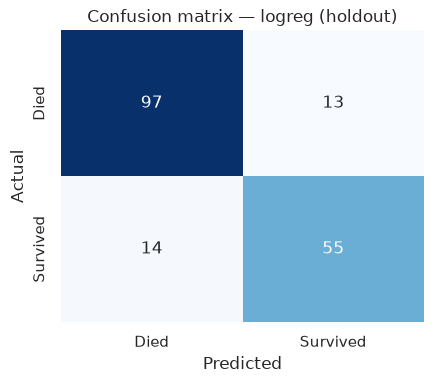

              precision    recall  f1-score   support

        Died       0.87      0.88      0.88       110
    Survived       0.81      0.80      0.80        69

    accuracy                           0.85       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



In [11]:
best_name = leaderboard.iloc[0]["model"]
best_pipe = fitted[best_name]["pipe"]
best_pred = fitted[best_name]["pred"]
print(f"Best model by F1: {best_name}")

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_name} (holdout)")
fig.tight_layout()
fig.savefig(ASSETS / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

print(classification_report(y_test, best_pred, target_names=["Died", "Survived"]))

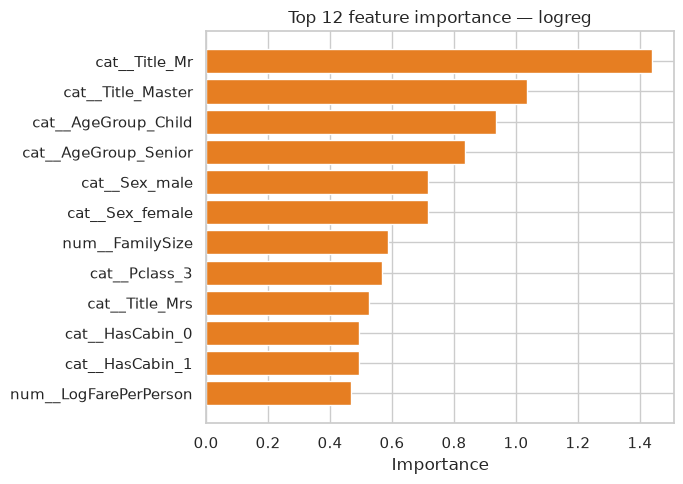

In [12]:
feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()
estimator = best_pipe.named_steps["model"]
if hasattr(estimator, "feature_importances_"):
    importance = estimator.feature_importances_
else:
    importance = np.abs(estimator.coef_[0])

top_k = 12
order = np.argsort(importance)[-top_k:]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(feature_names[order], importance[order], color="#e67e22")
ax.set_xlabel("Importance"); ax.set_title(f"Top {top_k} feature importance — {best_name}")
fig.tight_layout()
fig.savefig(ASSETS / "feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 8: Train on the full train set & generate the Kaggle submission

After picking the best model architecture, retrain it on **100% of the train data** (no holdout) to make the most of the data, then predict on `data/test.csv`. `test.csv` is feature-engineered using the exact statistics (`age_medians`, `fare_median`, `embarked_mode`) learned from train — not from test itself.

In [13]:
final_pipe = make_pipeline(type(best_pipe.named_steps["model"])(**best_pipe.named_steps["model"].get_params()))
final_pipe.fit(X, y)

test_engineered = engineer_features(test_df, **train_stats)
test_pred = final_pipe.predict(test_engineered[ALL_FEATURES])

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_pred.astype(int),
})
submission_path = OUTPUTS / "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Saved {len(submission)} predictions to: {submission_path}")
submission.head()

Saved 418 predictions to: outputs/submission.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## 🔹 Step 9: Save the model & results summary

Save the pipeline trained on the full train set (`outputs/model.joblib`) and `docs/assets/run_summary.json` so the README can display the numbers.

In [14]:
import joblib

joblib.dump(final_pipe, OUTPUTS / "model.joblib")

summary = {
    "best_model": best_name,
    "survival_rate": float(y.mean()),
    "n_train": int(len(X_train)),
    "n_holdout": int(len(X_test)),
    "accuracy_holdout": float(accuracy_score(y_test, best_pred)),
    "f1_holdout": float(f1_score(y_test, best_pred)),
    "leaderboard": leaderboard.to_dict(orient="records"),
    "classification_report": classification_report(y_test, best_pred, output_dict=True),
    "n_test_predictions": int(len(submission)),
    "submission_path": str(submission_path.resolve()),
}
with open(ASSETS / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved: outputs/model.joblib, outputs/submission.csv, docs/assets/run_summary.json")
print(json.dumps({k: summary[k] for k in ["best_model", "accuracy_holdout", "f1_holdout"]}, indent=2))

Saved: outputs/model.joblib, outputs/submission.csv, docs/assets/run_summary.json
{
  "best_model": "logreg",
  "accuracy_holdout": 0.8491620111731844,
  "f1_holdout": 0.8029197080291971
}


## ✅ Conclusion

- **Sex** and **Pclass** are the two strongest predictors — women and first-class passengers survived at a much higher rate.
- Feature engineering (`Title`, `FamilySize`, `IsAlone`, `HasCabin`, `FarePerPerson`) helps the model exploit hidden information in the raw columns better than using them directly.
- Among the 3 models compared, boosting/ensemble models usually edge out Logistic Regression on F1, but the gap is small — with a small dataset (~900 rows), complex models can easily overfit without controlling depth.
- `Age` and `Embarked` are imputed using statistics learned from **train only**, avoiding data leakage when applied to test/production.

**Possible next steps:** cross-validation instead of a single holdout split, hyperparameter search (GridSearch/Optuna), model stacking, or extracting extra features from `Ticket`.